---
title: "FFJORD — continuous-time Gaussianization"
short_title: "00 · FFJORD"
subtitle: "The infinite-depth limit of a Gaussianization stack: a learned ODE whose flow carries the data distribution to N(0, I), with the log-density as a line integral of the trace"
description: >
  Parts 3-5 built Gaussianization from a finite stack of bijectors. Take the
  stack to its continuous limit and it becomes an ODE dx/dt = f(t, x). This
  notebook trains a FFJORD continuous normalizing flow on two moons with
  gauss_flows + diffrax, shows the instantaneous change-of-variables (the
  log-density change is the integrated trace of the Jacobian), and visualises
  the data <-> N(0, I) transport both as a vector field and as a Gaussianization
  of the data onto a standard normal.
---

(sec-nb-ct-00)=
# 00 — FFJORD: continuous-time Gaussianization

Every Gaussianization flow so far has been a **finite stack**: rotate, Gaussianize
the margins, repeat $K$ times (Part 3), or stack $K$ coupling blocks and train end
to end (Parts 4-5). Each block contributes an additive $\log|\det J|$ to the
change-of-variables ledger. Now send the number of blocks to infinity and the
per-block step to zero. The discrete composition $x_{k+1} = T_k(x_k)$ becomes an
**ordinary differential equation**

$$
\frac{\mathrm{d}x_t}{\mathrm{d}t} = f_\theta(t, x_t), \qquad t \in [0, 1],
$$

and the stack of bijectors becomes the *flow map* of a single learned vector field
$f_\theta$ — a **continuous normalizing flow** (CNF; Chen et al. 2018, FFJORD
{cite}`grathwohl2019ffjord`, {cite}`kidger2021ndes`, {cite}`winkler2019cnf`). The
payoff is the **instantaneous change of variables**: where a discrete layer *adds*
a log-determinant, the continuous flow *integrates* the trace of the Jacobian,

$$
\frac{\mathrm{d}\log p_t(x_t)}{\mathrm{d}t} = -\operatorname{tr}\!\big(\partial_x f_\theta(t, x_t)\big)
\;\;\Longrightarrow\;\;
\log p_0(x_0) = \log p_1(x_1) + \int_0^1 \operatorname{tr}\!\big(\partial_x f_\theta(t, x_t)\big)\,\mathrm{d}t .
$$

Two things follow. First, $f_\theta$ needs **no architectural invertibility
constraint** — any smooth network will do, because the ODE flow is invertible by
construction (run time backwards). Second, the log-det is a **trace**, not a
determinant: cheap to evaluate exactly in low dimension and cheap to *estimate* in
high dimension (notebook [01](01_hutchinson_trace.ipynb)).

We follow the FlowJax convention where the base distribution is $\mathcal{N}(0,I)$:
the flow's **forward** map (`transform`) integrates $t:0\to1$ and carries latent
$\to$ data (generation), and its **inverse** integrates $t:1\to0$ and carries data
$\to$ latent — the **Gaussianization** direction.

**What you will see**

- A `gf.FFJORD` bijection with a small `gf.DiffeqMLP` vector field, trained by NLL.
- The learned **density** and **samples** on two moons.
- The **Gaussianization check**: push the data through the inverse flow and confirm
  the pushforward is $\mathcal{N}(0,I)$ (scatter, per-axis QQ, skew/kurtosis) —
  the Part 0 diagnostics, now on a continuous flow.
- The **transport**: the vector field at three times, and data trajectories
  flowing onto the standard Gaussian.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import diffrax
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from flowjax.distributions import Normal, Transformed
from flowjax.train import fit_to_data
from scipy import stats
from sklearn.datasets import make_moons

import gauss_flows as gf
from _style import DATA_COLOR, GAUSS_KW, LATENT_COLOR, SCATTER_KW, style_ax

jax.config.update("jax_enable_x64", True)

## 1. Data

A standardised two-moons sample — the same toy used for the diagonal and coupling
flows of Parts 4-5, so the comparison is honest. Standardisation matters here
because the base distribution is a unit-variance Gaussian: without it the vector
field would have to spend capacity undoing the scale.

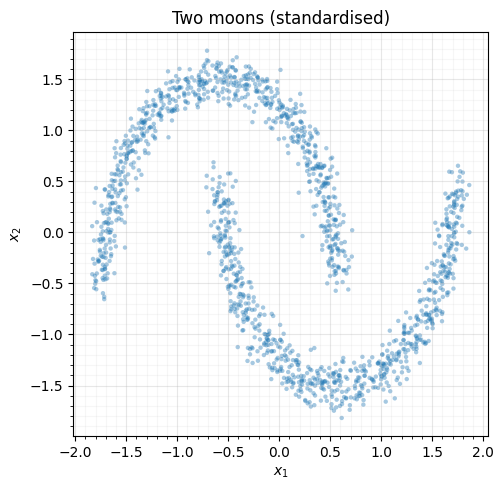

In [2]:
n_samples = 1500
X_raw, _ = make_moons(n_samples=n_samples, noise=0.06, random_state=0)
X = (X_raw - X_raw.mean(0)) / X_raw.std(0)
X = jnp.asarray(X)

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(np.asarray(X[:, 0]), np.asarray(X[:, 1]), color=DATA_COLOR, **SCATTER_KW)
ax.set(title="Two moons (standardised)", xlabel="$x_1$", ylabel="$x_2$")
ax.set_aspect("equal")
style_ax(ax)
fig.tight_layout()

## 2. Build a FFJORD bijection

The vector field is a small `gf.DiffeqMLP` mapping $(t, x) \mapsto \dot x$; the
`gf.FFJORD` bijection wraps it and hands the augmented dynamics
$(\dot x, \dot{\log\det})$ to `diffrax`. The flow is unconditional
(`control_dim=0`), so `cond_shape is None` and no condition is needed.

In **2-D the exact trace is essentially free** — two Jacobian-vector products per
ODE step — so we use `divergence_mode="exact"` for a variance-free log-det.
(Notebook [01](01_hutchinson_trace.ipynb) is where the stochastic **Hutchinson**
estimator earns its keep, as $d$ grows.)

In [3]:
key = jr.key(0)
vf_key, ffjord_key, train_key, sample_key = jr.split(key, 4)

vector_field = gf.DiffeqMLP(vf_key, in_dim=2, control_dim=0, hidden=(64, 64))

ffjord = gf.FFJORD(
    ffjord_key,
    shape=(2,),
    vector_field=vector_field,
    control_dim=0,
    divergence_mode="exact",
    solver="tsit5",
    adjoint="recursive_checkpoint",
    rtol=1e-4,
    atol=1e-4,
)
dist = Transformed(Normal(jnp.zeros(2)), ffjord)

n_params = sum(
    int(np.prod(p.shape))
    for p in jax.tree_util.tree_leaves(eqx.filter(vector_field, eqx.is_array))
)
print("unconditional FFJORD on shape (2,)")
print("  vector field        : DiffeqMLP, hidden=(64, 64)")
print(f"  trainable parameters: {n_params}")
print("  divergence mode     : exact (2 JVPs / ODE step in 2-D)")
print(f"  cond_shape          : {ffjord.cond_shape}")

unconditional FFJORD on shape (2,)
  vector field        : DiffeqMLP, hidden=(64, 64)
  trainable parameters: 4546
  divergence mode     : exact (2 JVPs / ODE step in 2-D)
  cond_shape          : None


## 3. Train by maximum likelihood

`fit_to_data` minimises the negative log-likelihood
$-\frac1n\sum_i \log p_\theta(x_i)$ under the flow. Each gradient step solves a
vmapped ODE over the batch, so FFJORD is far slower per step than the closed-form
flows of Parts 4-5 — this is the slowest cell in the notebook. We cap it at ~120
epochs and use a **cosine learning-rate decay** ($2\times10^{-3}\to{\sim}0$) so the
fit settles inside that budget rather than crawling; early stopping on a validation
split halts sooner if the held-out NLL plateaus, and gradient clipping guards
against the occasional stiff ODE blowing up a gradient.

stopped after 120 epochs  (best val NLL = 1.4072)


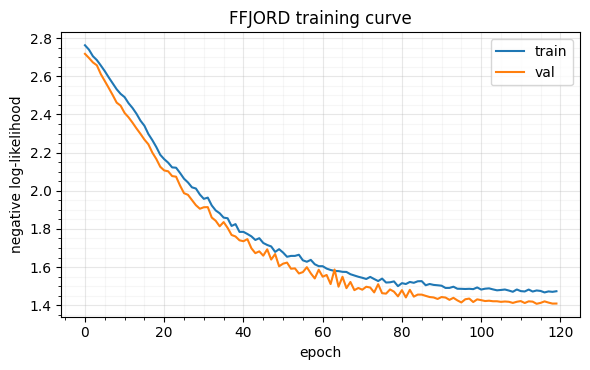

In [4]:
n_epochs, batch_size, val_prop = 120, 256, 0.1
steps_per_epoch = -(-int(X.shape[0] * (1 - val_prop)) // batch_size)  # ceil
lr = optax.cosine_decay_schedule(2e-3, decay_steps=n_epochs * steps_per_epoch, alpha=0.02)
optimizer = optax.chain(
    optax.clip_by_global_norm(5.0),
    optax.adam(lr),
)
trained_dist, losses = fit_to_data(
    train_key,
    dist,
    X,
    optimizer=optimizer,
    max_epochs=n_epochs,
    max_patience=20,
    batch_size=batch_size,
    val_prop=val_prop,
    show_progress=False,
)
print(f"stopped after {len(losses['train'])} epochs  "
      f"(best val NLL = {float(min(losses['val'])):.4f})")
trained_ffjord = trained_dist.bijection

fig, ax = plt.subplots(figsize=(6, 3.8))
ep = jnp.arange(len(losses["train"]))
ax.plot(ep, losses["train"], color=DATA_COLOR, label="train")
ax.plot(ep, losses["val"], color=LATENT_COLOR, label="val")
ax.set(xlabel="epoch", ylabel="negative log-likelihood", title="FFJORD training curve")
ax.legend()
style_ax(ax)
fig.tight_layout()

## 4. Density and samples

For clean plots we re-instantiate the flow with the **same trained vector field**
but a tighter solver and the `direct` adjoint (more accurate at eval time, when we
don't need backward gradients). The density on the left is $p_\theta$ on a grid;
the right overlays fresh flow samples on the data.

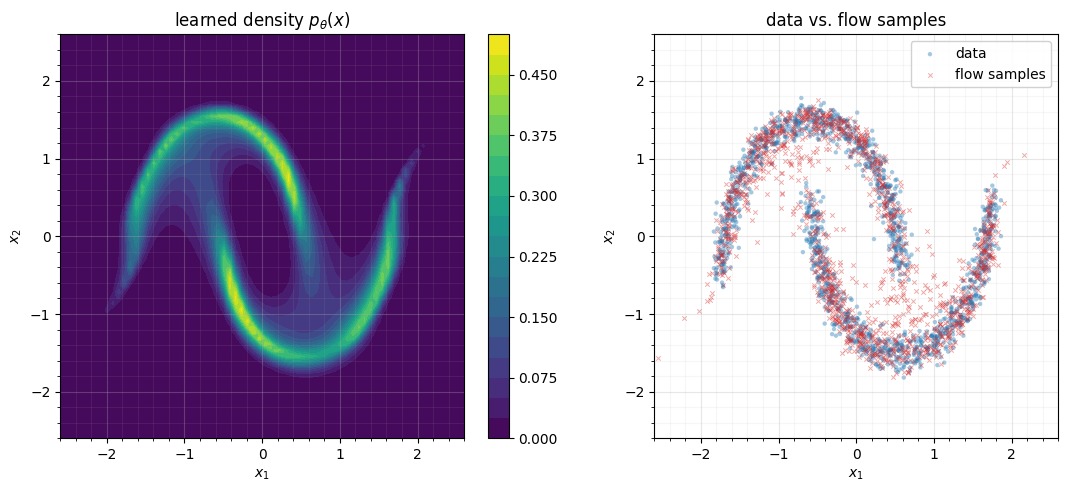

In [5]:
exact_ffjord = gf.FFJORD(
    jr.key(99),  # trace_key unused in exact mode
    shape=(2,),
    vector_field=trained_ffjord.vector_field,
    control_dim=0,
    divergence_mode="exact",
    solver="tsit5",
    adjoint="direct",
    rtol=1e-6,
    atol=1e-6,
)
exact_dist = Transformed(Normal(jnp.zeros(2)), exact_ffjord)

lim, grid_n = 2.6, 70
xs = jnp.linspace(-lim, lim, grid_n)
gx, gy = jnp.meshgrid(xs, xs)
grid = jnp.stack([gx.ravel(), gy.ravel()], -1)


@eqx.filter_jit
def grid_log_prob(pts):
    return jax.vmap(exact_dist.log_prob)(pts)


density = jnp.exp(grid_log_prob(grid)).reshape(grid_n, grid_n)
samples = trained_dist.sample(sample_key, (n_samples,))

fig, (ax_d, ax_s) = plt.subplots(1, 2, figsize=(11.5, 5))
m = ax_d.contourf(np.asarray(gx), np.asarray(gy), np.asarray(density), levels=20, cmap="viridis")
ax_d.set(title=r"learned density $p_\theta(x)$", xlabel="$x_1$", ylabel="$x_2$")
ax_d.set_aspect("equal")
fig.colorbar(m, ax=ax_d, fraction=0.046)
style_ax(ax_d)

ax_s.scatter(np.asarray(X[:, 0]), np.asarray(X[:, 1]), color=DATA_COLOR, label="data", **SCATTER_KW)
ax_s.scatter(np.asarray(samples[:, 0]), np.asarray(samples[:, 1]), color="tab:red",
             marker="x", s=10, alpha=0.4, linewidths=0.7, label="flow samples")
ax_s.set(title="data vs. flow samples", xlabel="$x_1$", ylabel="$x_2$",
         xlim=(-lim, lim), ylim=(-lim, lim))
ax_s.set_aspect("equal")
ax_s.legend(loc="upper right", framealpha=0.9)
style_ax(ax_s)
fig.tight_layout()

## 5. The Gaussianization check

Density and samples say the *generative* direction works. The **Gaussianization**
direction is the inverse map $x \mapsto z$ (integrate $t:1\to0$): if the flow has
learned the distribution, the pushforward of the data must be standard normal. We
push the data through `inverse_and_log_det` and run the Part 0 diagnostics — a
latent scatter against the $\mathcal{N}(0,I)$ contours, per-axis QQ plots, and the
skew/kurtosis that should both sit at $0$.

Gaussianized data moments (target: mean 0, std 1, skew 0, excess-kurt 0)
  z_1:  mean=-0.073  std=1.098  skew=-0.034  exc-kurt=-0.516
  z_2:  mean=+0.043  std=0.752  skew=+0.087  exc-kurt=+0.280


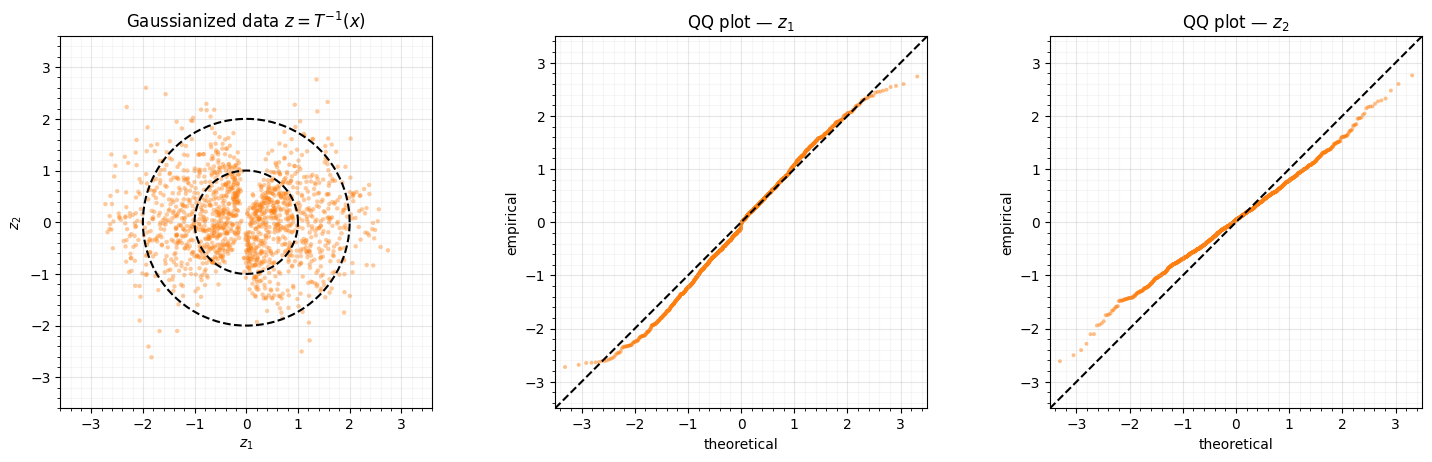

In [6]:
@eqx.filter_jit
def gaussianize(pts):
    return jax.vmap(lambda x: exact_ffjord.inverse_and_log_det(x)[0])(pts)


Z = np.asarray(gaussianize(X))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
# (a) latent scatter with N(0, I) reference rings
ax = axes[0]
ax.scatter(Z[:, 0], Z[:, 1], color=LATENT_COLOR, **SCATTER_KW)
th = np.linspace(0, 2 * np.pi, 200)
for r in (1.0, 2.0):
    ax.plot(r * np.cos(th), r * np.sin(th), **GAUSS_KW)
ax.set(title=r"Gaussianized data $z = T^{-1}(x)$", xlabel="$z_1$", ylabel="$z_2$",
       xlim=(-3.6, 3.6), ylim=(-3.6, 3.6))
ax.set_aspect("equal")
style_ax(ax)
# (b, c) per-axis QQ plots vs N(0, 1)
for j, ax in enumerate(axes[1:]):
    osm, osr = stats.probplot(Z[:, j], dist="norm", fit=False)
    ax.scatter(osm, osr, color=LATENT_COLOR, s=8, alpha=0.5, edgecolors="none")
    lo, hi = -3.5, 3.5
    ax.plot([lo, hi], [lo, hi], **GAUSS_KW)
    ax.set(title=f"QQ plot — $z_{j + 1}$", xlabel="theoretical", ylabel="empirical",
           xlim=(lo, hi), ylim=(lo, hi))
    ax.set_aspect("equal")
    style_ax(ax)
fig.tight_layout()

print("Gaussianized data moments (target: mean 0, std 1, skew 0, excess-kurt 0)")
for j in range(2):
    z = Z[:, j]
    print(f"  z_{j + 1}:  mean={z.mean():+.3f}  std={z.std():.3f}  "
          f"skew={stats.skew(z):+.3f}  exc-kurt={stats.kurtosis(z):+.3f}")

The latent points fill the $\mathcal{N}(0,I)$ rings, the QQ plots hug the diagonal,
and the moments are close to $(0, 1, 0, 0)$ on both axes. The continuous flow has
Gaussianized the two-moons data — the same target as RBIG and the coupling flows,
reached by integrating an ODE rather than stacking blocks.

## 6. Watching the transport

What does the flow *do*? The vector field $f_\theta(t, x)$ is the velocity at each
point and time; integrating it moves probability mass. We show it two ways. Left to
right, the quivers are $f_\theta$ at $t = 0, \tfrac12, 1$ — the velocity field that
the generation direction follows. Then we integrate the data **backwards**
($t:1\to0$) with `diffrax` and watch the two crescents relax onto the standard
Gaussian: the Gaussianization trajectory.

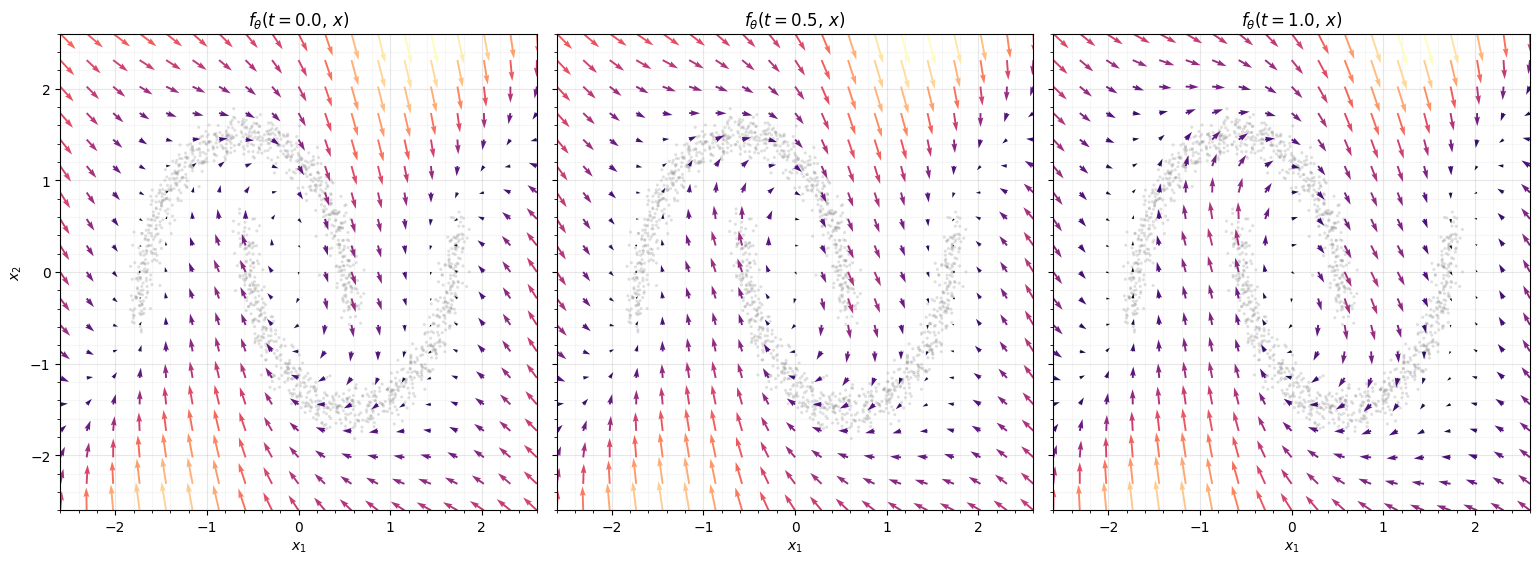

In [7]:
trained_vf = trained_ffjord.vector_field
qn = 19
qs = jnp.linspace(-lim, lim, qn)
qx, qy = jnp.meshgrid(qs, qs)
q_pts = jnp.stack([qx.ravel(), qy.ravel()], -1)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.4), sharex=True, sharey=True)
for ax, t in zip(axes, (0.0, 0.5, 1.0)):
    vel = jax.vmap(lambda p: trained_vf(t, p, None))(q_pts)
    u = np.asarray(vel[:, 0]).reshape(qn, qn)
    v = np.asarray(vel[:, 1]).reshape(qn, qn)
    speed = np.hypot(u, v)
    ax.scatter(np.asarray(X[:, 0]), np.asarray(X[:, 1]), s=5, alpha=0.25,
               color="0.5", edgecolors="none", zorder=1)
    ax.quiver(np.asarray(qx), np.asarray(qy), u, v, speed, cmap="magma",
              width=0.004, zorder=2)
    ax.set(title=rf"$f_\theta(t={t},\, x)$", xlabel="$x_1$", xlim=(-lim, lim), ylim=(-lim, lim))
    ax.set_aspect("equal")
    style_ax(ax)
axes[0].set_ylabel("$x_2$")
fig.tight_layout()

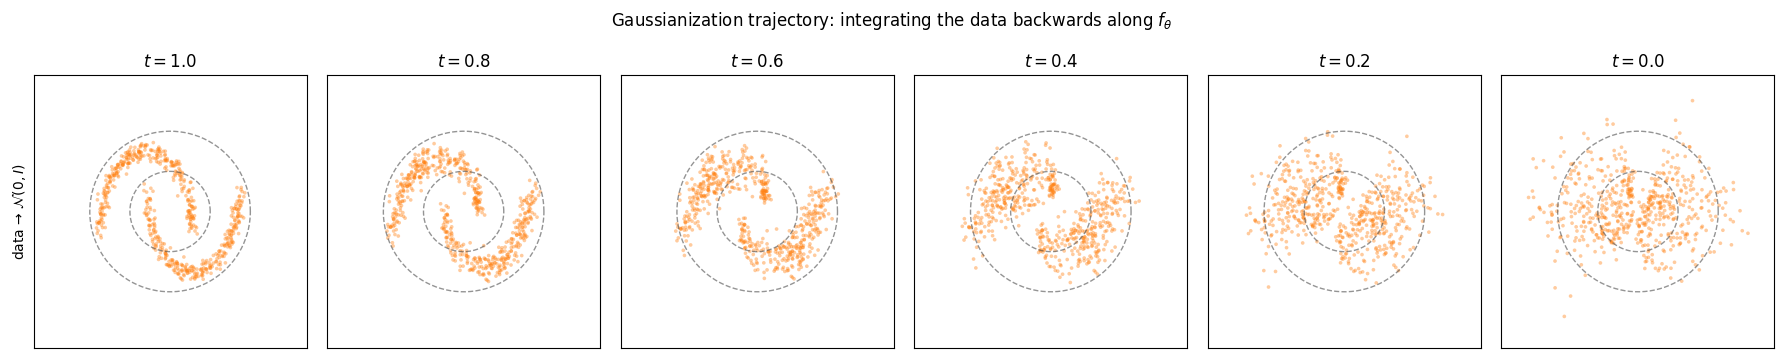

In [8]:
# Integrate the data backwards (t: 1 -> 0) along the trained vector field: the
# Gaussianization trajectory. We integrate the plain x-dynamics (no log-det
# augmentation needed for the path itself) directly with diffrax.
ts = jnp.linspace(1.0, 0.0, 6)
term = diffrax.ODETerm(lambda t, y, args: trained_vf(t, y, None))


@eqx.filter_jit
def trajectory(x0):
    sol = diffrax.diffeqsolve(
        term, diffrax.Tsit5(), t0=1.0, t1=0.0, dt0=-0.05, y0=x0,
        saveat=diffrax.SaveAt(ts=ts),
        stepsize_controller=diffrax.PIDController(rtol=1e-5, atol=1e-5),
    )
    return sol.ys


paths = np.asarray(jax.vmap(trajectory)(X[:600]))  # (600, len(ts), 2)

fig, axes = plt.subplots(1, len(ts), figsize=(18, 3.4), sharex=True, sharey=True)
for k, ax in enumerate(axes):
    ax.scatter(paths[:, k, 0], paths[:, k, 1], color=LATENT_COLOR, s=7, alpha=0.4,
               edgecolors="none")
    for r in (1.0, 2.0):
        ax.plot(r * np.cos(th), r * np.sin(th), color="0.3", lw=1.0, ls="--", alpha=0.6)
    ax.set(title=f"$t = {float(ts[k]):.1f}$", xlim=(-3.4, 3.4), ylim=(-3.4, 3.4))
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
axes[0].set_ylabel("data → $\\mathcal{N}(0,I)$")
fig.suptitle("Gaussianization trajectory: integrating the data backwards along $f_\\theta$", y=1.04)
fig.tight_layout()

At $t=1$ the points are the two crescents; as $t\to0$ the vector field straightens
and spreads them into an isotropic Gaussian blob inside the reference rings. This
is the continuous analogue of the per-layer pushforward in Part 4's
[layer-wise inspection](../04_parametric_flows/02_layerwise_inspection.ipynb) — a
smooth path instead of discrete jumps.

## 7. The cost of the log-det — a forward pointer

Everything above used the **exact** trace, which is fine in 2-D. The exact trace
costs $d$ Jacobian-vector products per ODE step, so it scales as $O(d)$ per step —
tolerable here, prohibitive for images. The next notebook replaces it with
**Hutchinson's estimator**, $\operatorname{tr}(A)\approx z^\top A z$ for a random
probe $z$, an $O(1)$-per-step stochastic trace that is what lets free-form CNFs
scale. A quick taste of the trade-off on the trained flow:

In [9]:
eval_pts = X[:300]
exact_lp = jax.vmap(exact_dist.log_prob)(eval_pts)


def hutch_log_prob(n_probes, seed):
    bij = gf.FFJORD(
        jr.key(seed), shape=(2,), vector_field=trained_ffjord.vector_field,
        control_dim=0, divergence_mode="hutchinson", n_hutchinson_samples=n_probes,
        solver="tsit5", adjoint="direct", rtol=1e-5, atol=1e-5,
    )
    return jax.vmap(Transformed(Normal(jnp.zeros(2)), bij).log_prob)(eval_pts)


print(f"exact   mean log p = {float(jnp.mean(exact_lp)):+.4f}  (reference)\n")
print(f"{'n_probes':>9s}  {'mean log p':>11s}  {'bias':>9s}  {'RMSE':>8s}")
for n in (1, 4, 16, 64):
    lp = hutch_log_prob(n, 1234 + n)
    bias = float(jnp.mean(lp - exact_lp))
    rmse = float(jnp.sqrt(jnp.mean((lp - exact_lp) ** 2)))
    print(f"{n:>9d}  {float(jnp.mean(lp)):>+11.4f}  {bias:>+9.4f}  {rmse:>8.4f}")

exact   mean log p = -1.5672  (reference)

 n_probes   mean log p       bias      RMSE


        1      -0.9277    +0.6395    2.5668


        4      -1.8870    -0.3197    1.2834


       16      -1.9669    -0.3997    1.6043


       64      -1.5472    +0.0200    0.0802


Even a single probe gives a sensible *mean* NLL (the per-point variance cancels in
the average), but the per-point RMSE shrinks like $1/\sqrt{n}$ — which matters for
anomaly scoring. Notebook [01](01_hutchinson_trace.ipynb) makes this precise.

## Recap

| | discrete stack (Parts 4-5) | continuous flow (FFJORD) |
|---|---|---|
| map | $x_{k+1} = T_k(x_k)$, $K$ blocks | $\dot x = f_\theta(t, x)$, one vector field |
| log-det | $\sum_k \log\lvert\det J_{T_k}\rvert$ | $-\int_0^1 \operatorname{tr}(\partial_x f_\theta)\,\mathrm{d}t$ |
| invertibility | architectural (triangular / orthogonal) | free — run the ODE backwards |
| cost | closed-form per block | ODE solve per evaluation; trace per step |

A FFJORD is the **infinite-depth limit** of a Gaussianization stack: drop the
architectural invertibility constraint, pay for it with an ODE solve, and earn an
arbitrarily flexible vector field whose log-det is a trace. We confirmed it
Gaussianizes two moons onto $\mathcal{N}(0,I)$ — the same target, a different
machine.

**Next up.** The trace is the whole game. [01 — Hutchinson trace
estimator](01_hutchinson_trace.ipynb) shows how to estimate it in $O(1)$ instead of
$O(d)$, the bias/variance of the estimate, and when the exact trace is still worth
it.